# ============================================================
# Notebook 05 — Temporal Fusion Transformer (TFT)
# FI-2010 Level-2 Order Book Classification
# ============================================================

# 05 — Temporal Fusion Transformer (TFT)

## Objective

This notebook develops the LOB-side component of QuantFormer using a
Temporal Fusion Transformer (TFT)-style architecture on FI-2010 data.

The model uses 100-step Level-2 Order Book sequences with 143 features
to predict three price-movement classes: Down, Stable, and Up.

The FinBERT sentiment component is handled separately in Notebook 04.
Multimodal fusion will be performed in a later stage.

In [4]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully.")

All libraries imported successfully.


# ============================================================
# 2. Reproducibility and Device Configuration
# ============================================================

In [5]:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Random seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Random seed: 42
Device: cpu


# ============================================================
# 3. Load Processed FI-2010 Dataset
# ============================================================

In [6]:

DATA_DIR = "../datasets/processed/FI2010"

X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(DATA_DIR, "X_val.npy"))
X_test  = np.load(os.path.join(DATA_DIR, "X_test.npy"))

y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(DATA_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print("FI-2010 data loaded successfully!")
print()
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)
print()
print("y_train shape:", y_train.shape)
print("y_val shape:  ", y_val.shape)
print("y_test shape: ", y_test.shape)

FI-2010 data loaded successfully!

X_train shape: (25450, 100, 143)
X_val shape:   (6289, 100, 143)
X_test shape:  (362301, 100, 143)

y_train shape: (25450,)
y_val shape:   (6289,)
y_test shape:  (362301,)


# ============================================================
# 4. Verify Target Labels
# ============================================================

In [7]:
print("Unique labels in training set:", np.unique(y_train))
print("Unique labels in validation set:", np.unique(y_val))
print("Unique labels in test set:", np.unique(y_test))
print("\nTraining label counts:")
print(pd.Series(y_train).value_counts().sort_index())

Unique labels in training set: [0 1 2]
Unique labels in validation set: [0 1 2]
Unique labels in test set: [0 1 2]

Training label counts:


0    10267
1     6011
2     9172
Name: count, dtype: int64


# ============================================================
# 5. Dataset Information
# ============================================================

In [8]:
SEQUENCE_LENGTH = X_train.shape[1]
INPUT_SIZE = X_train.shape[2]
NUM_CLASSES = len(np.unique(y_train))

print("Sequence length:", SEQUENCE_LENGTH)
print("Number of input features:", INPUT_SIZE)
print("Number of classes:", NUM_CLASSES)

Sequence length: 100
Number of input features: 143
Number of classes: 3


# ============================================================
# 6. Class Distribution
# ============================================================

In [9]:


class_names = {
    0: "Down",
    1: "Stable",
    2: "Up"
}

labels, counts = np.unique(y_train, return_counts=True)

print("Training class distribution:")

for label, count in zip(labels, counts):
    print(f"{label} ({class_names[label]}): {count}")

Training class distribution:
0 (Down): 10267
1 (Stable): 6011
2 (Up): 9172


# ============================================================
# 7. Visualize Class Distribution
# ============================================================


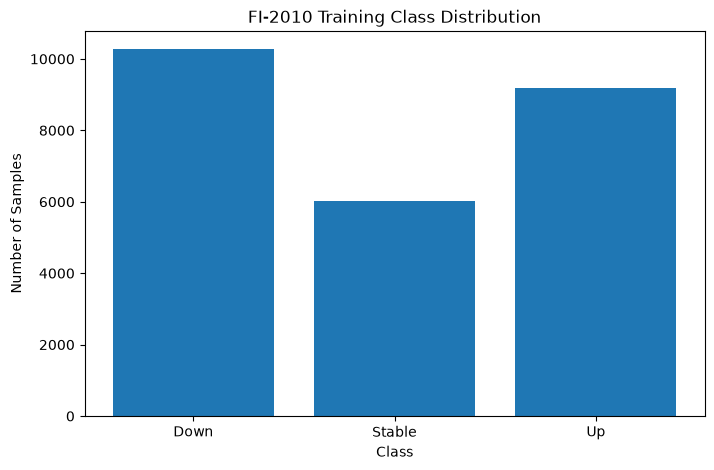

In [10]:

plt.figure(figsize=(8, 5))

plt.bar(
    [class_names[label] for label in labels],
    counts
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("FI-2010 Training Class Distribution")
plt.show()

# ============================================================
# 8. PyTorch Dataset
# ============================================================

In [11]:
class LOBDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = LOBDataset(X_train, y_train)
val_dataset = LOBDataset(X_val, y_val)
test_dataset = LOBDataset(X_test, y_test)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 25450
Validation samples: 6289
Test samples: 362301


# ============================================================
# 9. Verify Dataset Sample
# ============================================================

In [12]:
sample_X, sample_y = train_dataset[0]

print("Sample X shape:", sample_X.shape)
print("Sample label:", sample_y.item())
print("Sample X dtype:", sample_X.dtype)
print("Sample y dtype:", sample_y.dtype)

Sample X shape: torch.Size([100, 143])
Sample label: 0
Sample X dtype: torch.float32
Sample y dtype: torch.int64


# ============================================================
# 10. DataLoaders
# ============================================================

In [13]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Batch size:", BATCH_SIZE)
print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

Batch size: 64
Number of training batches: 398
Number of validation batches: 99
Number of test batches: 5661


# ============================================================
# 11. DataLoader Sanity Check
# ============================================================


In [14]:

X_batch, y_batch = next(iter(train_loader))

print("Batch X shape:", X_batch.shape)
print("Batch y shape:", y_batch.shape)
print("Batch X dtype:", X_batch.dtype)
print("Batch y dtype:", y_batch.dtype)

Batch X shape: torch.Size([64, 100, 143])
Batch y shape: torch.Size([64])
Batch X dtype: torch.float32
Batch y dtype: torch.int64


# ============================================================
# 12. TFT Input Shape Verification
# ============================================================

In [15]:
print("TFT INPUT SHAPE VERIFICATION")
print("=" * 40)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\nSequence length:", X_train.shape[1])
print("Number of features:", X_train.shape[2])
print("Number of classes:", len(np.unique(y_train)))

TFT INPUT SHAPE VERIFICATION
X_train shape: (25450, 100, 143)
X_val shape: (6289, 100, 143)
X_test shape: (362301, 100, 143)

Sequence length: 100
Number of features: 143
Number of classes: 3


# ============================================================
# 13. Memory-Efficient PyTorch Dataset
# ============================================================

In [ ]:
class LOBDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        X = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)

        return X, y


# Create datasets
train_dataset = LOBDataset(X_train, y_train)
val_dataset = LOBDataset(X_val, y_val)
test_dataset = LOBDataset(X_test, y_test)

print("Memory-efficient PyTorch datasets created successfully!")
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Memory-efficient PyTorch datasets created successfully!
Train samples: 25450
Validation samples: 6289
Test samples: 362301


# ============================================================
# 14. DataLoaders
# ============================================================

In [19]:


BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created successfully!")
print("Batch size:", BATCH_SIZE)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created successfully!
Batch size: 64
Train batches: 398
Validation batches: 99
Test batches: 5661


# ============================================================
# 15. DataLoader Batch Verification
# ============================================================

In [20]:

X_batch, y_batch = next(iter(train_loader))

print("Batch X shape:", X_batch.shape)
print("Batch y shape:", y_batch.shape)
print("X dtype:", X_batch.dtype)
print("y dtype:", y_batch.dtype)
print("Labels in batch:", torch.unique(y_batch))

Batch X shape: torch.Size([64, 100, 143])
Batch y shape: torch.Size([64])
X dtype: torch.float32
y dtype: torch.int64
Labels in batch: tensor([0, 2])


# ============================================================
# 16. Model Configuration
# ============================================================


In [ ]:


INPUT_SIZE = X_train.shape[-1]
SEQUENCE_LENGTH = X_train.shape[1]
NUM_CLASSES = len(np.unique(y_train))

HIDDEN_SIZE = 64
LSTM_LAYERS = 2
NUM_HEADS = 4
DROPOUT = 0.1

print("Model Configuration")
print("-------------------")
print("Input features:", INPUT_SIZE)
print("Sequence length:", SEQUENCE_LENGTH)
print("Hidden size:", HIDDEN_SIZE)
print("LSTM layers:", LSTM_LAYERS)
print("Attention heads:", NUM_HEADS)
print("Dropout:", DROPOUT)
print("Number of classes:", NUM_CLASSES)

Model Configuration
-------------------
Input features: 143
Sequence length: 100
Hidden size: 64
LSTM layers: 2
Attention heads: 4
Dropout: 0.1
Number of classes: 3


# ============================================================
# 17. Device
# ============================================================


In [22]:


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA not available. Using CPU.")

Device: cpu
CUDA not available. Using CPU.


# ============================================================
# 18. PyTorch Environment Check
# ============================================================

In [24]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

PyTorch version: 2.13.0+cpu
CUDA available: False
Device: cpu


# ============================================================
# 19. Check PyTorch Forecasting
# ============================================================

In [25]:


try:
    import pytorch_forecasting

    print("PyTorch Forecasting version:",
          pytorch_forecasting.__version__)
    print("PyTorch Forecasting is installed.")
    
except ImportError:
    print("PyTorch Forecasting is NOT installed.")

PyTorch Forecasting is NOT installed.


# ============================================================
# 20. Python Environment Check
# ============================================================

In [ ]:
import sys
import subprocess

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

print("\nPip version:")
result = subprocess.run(
    [sys.executable, "-m", "pip", "--version"],
    capture_output=True,
    text=True
)
print(result.stdout)

Python version:
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]

Python executable:
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\python.exe

Pip version:
pip 25.0.1 from c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip (python 3.12)




In [27]:
import pytorch_forecasting

print("PyTorch Forecasting version:", pytorch_forecasting.__version__)
print("PyTorch Forecasting imported successfully!")

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Forecasting version: 1.8.0
PyTorch Forecasting imported successfully!


# ============================================================
# 21. PyTorch Forecasting Imports
# ============================================================

In [28]:
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.metrics import CrossEntropy

print("PyTorch Forecasting TFT components imported successfully!")

PyTorch Forecasting TFT components imported successfully!


# ============================================================
# 22. Prepare a Small FI-2010 Sample for TFT
# ============================================================

In [30]:
SAMPLE_SIZE = 1000

X_sample = X_train[:SAMPLE_SIZE]
y_sample = y_train[:SAMPLE_SIZE]

print("Sample X shape:", X_sample.shape)
print("Sample y shape:", y_sample.shape)

Sample X shape: (1000, 100, 143)
Sample y shape: (1000,)


# ============================================================
# 23. Verify Sequence Structure
# ============================================================

In [ ]:

print("Sequence length:", X_sample.shape[1])
print("Number of features:", X_sample.shape[2])
print("Number of target classes:", len(np.unique(y_sample)))

print("\nTarget classes:", np.unique(y_sample))

Sequence length: 100
Number of features: 143
Number of target classes: 3

Target classes: [0 1 2]


# ============================================================
# 24. Create Small DataFrame for TFT
# ============================================================

In [34]:
feature_names = [f"feature_{i}" for i in range(INPUT_SIZE)]

rows = []

for sample_idx in range(SAMPLE_SIZE):
    for time_idx in range(SEQUENCE_LENGTH):
        row = {
            "group_id": str(sample_idx),
            "time_idx": time_idx,
            "target": int(y_sample[sample_idx])
        }

        for feature_idx in range(INPUT_SIZE):
            row[feature_names[feature_idx]] = X_sample[
                sample_idx, time_idx, feature_idx
            ]

        rows.append(row)

tft_df = pd.DataFrame(rows)

print("TFT DataFrame created!")
print("Shape:", tft_df.shape)
print("\nFirst 5 rows:")
display(tft_df.head())

TFT DataFrame created!
Shape: (100000, 146)

First 5 rows:


,group_id,time_idx,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142
0,0,0,0,0.482926,-0.776752,0.480731,-0.549403,0.484685,-0.656643,0.480994,...,0.60972,0.608029,0.0,0.0,0.0,-0.157748,3.090395,3.062190,0.0,0.0
1,0,1,0,0.482926,-0.776752,0.482724,-0.672166,0.484685,-0.656643,0.480994,...,0.60972,0.608029,0.0,0.0,0.0,-0.157748,1.926612,1.904478,0.0,0.0
2,0,2,0,0.482926,-0.776752,0.479734,-0.534920,0.483690,-0.907925,0.476010,...,0.60972,0.608029,0.0,0.0,0.0,-0.157748,3.378460,3.348752,0.0,0.0
3,0,3,0,0.482926,-0.776752,0.480731,-0.672166,0.483690,-0.907925,0.480994,...,0.60972,0.608029,0.0,0.0,0.0,-0.157748,3.839364,3.807252,0.0,0.0
4,0,4,0,0.482926,-0.776752,0.478738,-0.652165,0.483690,-0.907925,0.479001,...,0.60972,0.608029,0.0,0.0,0.0,-0.157748,4.069816,4.036502,0.0,0.0


# ============================================================
# 25. Custom TFT Architecture
# ============================================================

In [37]:


class GatedResidualNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.1):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)

        self.gate = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout)

        self.skip = (
            nn.Linear(input_size, hidden_size)
            if input_size != hidden_size
            else nn.Identity()
        )

        self.norm = nn.LayerNorm(hidden_size)

    def forward(self, x):
        residual = self.skip(x)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        gate = torch.sigmoid(self.gate(x))
        x = gate * x

        return self.norm(x + residual)


class VariableSelectionNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.1):
        super().__init__()

        self.feature_weights = nn.Linear(
            input_size,
            input_size
        )

        self.projection = nn.Linear(
            input_size,
            hidden_size
        )

        self.grn = GatedResidualNetwork(
            hidden_size,
            hidden_size,
            dropout
        )

    def forward(self, x):
        # x shape: (batch, time, features)

        weights = torch.softmax(
            self.feature_weights(x),
            dim=-1
        )

        x = x * weights

        x = self.projection(x)

        x = self.grn(x)

        return x


class TFTClassifier(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        num_heads,
        lstm_layers,
        num_classes,
        dropout=0.1
    ):
        super().__init__()

        self.variable_selection = VariableSelectionNetwork(
            input_size,
            hidden_size,
            dropout
        )

        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.attention_norm = nn.LayerNorm(hidden_size)

        self.gating = nn.Linear(
            hidden_size,
            hidden_size
        )

        self.output_grn = GatedResidualNetwork(
            hidden_size,
            hidden_size,
            dropout
        )

        self.classifier = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        # Variable selection
        x = self.variable_selection(x)

        # LSTM encoder
        lstm_out, _ = self.lstm(x)

        # Multi-head temporal attention
        attention_out, attention_weights = self.attention(
            lstm_out,
            lstm_out,
            lstm_out
        )

        # Residual connection
        x = self.attention_norm(
            lstm_out + attention_out
        )

        # Gating
        gate = torch.sigmoid(
            self.gating(x)
        )

        x = gate * x

        # Use final time step
        x = x[:, -1, :]

        # Final GRN
        x = self.output_grn(x)

        # Classification
        logits = self.classifier(x)

        return logits, attention_weights


print("Custom TFT architecture defined successfully!")

Custom TFT architecture defined successfully!


# ============================================================
# 26. Create TFT Model
# ============================================================

In [ ]:


model = TFTClassifier(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_heads=NUM_HEADS,
    lstm_layers=LSTM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

model = model.to(device)

print(model)

TFTClassifier(
  (variable_selection): VariableSelectionNetwork(
    (feature_weights): Linear(in_features=143, out_features=143, bias=True)
    (projection): Linear(in_features=143, out_features=64, bias=True)
    (grn): GatedResidualNetwork(
      (fc1): Linear(in_features=64, out_features=64, bias=True)
      (fc2): Linear(in_features=64, out_features=64, bias=True)
      (gate): Linear(in_features=64, out_features=64, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (skip): Identity()
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    )
  )
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.1)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (attention_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (gating): Linear(in_features=64, out_features=64, bias=True)
  (output_grn): GatedResidualNetwork(
    (fc1): Linear(i

# ============================================================
# 27. Model Parameter Count
# ============================================================


In [ ]:

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

Total parameters: 142707
Trainable parameters: 142707


# ============================================================
# 28. Forward Pass Sanity Check
# ============================================================


In [40]:

model.eval()

with torch.no_grad():

    sample_X, sample_y = next(iter(train_loader))

    sample_X = sample_X.to(device)

    logits, attention_weights = model(sample_X)

print("Input shape:", sample_X.shape)
print("Logits shape:", logits.shape)
print("Attention shape:", attention_weights.shape)

Input shape: torch.Size([64, 100, 143])
Logits shape: torch.Size([64, 3])
Attention shape: torch.Size([64, 100, 100])


# ============================================================
# 29. Loss Function and Optimizer
# ============================================================

In [41]:

criterion = nn.CrossEntropyLoss()

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.001
Weight decay: 1e-05


# ============================================================
# 30. Learning Rate Scheduler
# ============================================================


In [42]:

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Learning-rate scheduler created successfully!")

Learning-rate scheduler created successfully!


# ============================================================
# 31. Single-Batch Training Sanity Check
# ============================================================

In [43]:

model.train()

X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

optimizer.zero_grad()

logits, attention_weights = model(X_batch)

loss = criterion(logits, y_batch)

loss.backward()

torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0
)

optimizer.step()

print("Single-batch training test successful!")
print("Batch loss:", loss.item())
print("Logits shape:", logits.shape)

Single-batch training test successful!
Batch loss: 1.243838906288147
Logits shape: torch.Size([64, 3])


# ============================================================
# 32. Training Configuration
# ============================================================

In [44]:

EPOCHS = 3
PATIENCE = 2

best_val_f1 = -float("inf")
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "val_f1": []
}

print("Training configuration")
print("----------------------")
print("Epochs:", EPOCHS)
print("Early stopping patience:", PATIENCE)
print("Best validation F1:", best_val_f1)

Training configuration
----------------------
Epochs: 3
Early stopping patience: 2
Best validation F1: -inf


# ============================================================
# 33. Validation Function
# ============================================================

In [45]:


def evaluate_model(model, data_loader, criterion, device):

    model.eval()

    total_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits, _ = model(X_batch)

            loss = criterion(logits, y_batch)

            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_targets.extend(
                y_batch.cpu().numpy()
            )

    average_loss = total_loss / len(data_loader)

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro"
    )

    return average_loss, accuracy, f1


print("Validation function created successfully!")

Validation function created successfully!


# ============================================================
# 34. TFT Training Loop
# ============================================================


In [46]:

EPOCHS = 3
PATIENCE = 2

best_val_f1 = -float("inf")
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "val_f1": []
}

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    all_train_predictions = []
    all_train_targets = []

    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits, _ = model(X_batch)

        loss = criterion(logits, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_train_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_train_targets.extend(
            y_batch.detach().cpu().numpy()
        )

    train_loss = running_loss / len(train_loader)

    train_accuracy = accuracy_score(
        all_train_targets,
        all_train_predictions
    )

    val_loss, val_accuracy, val_f1 = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "tft_best_model.pth"
        )

        print("  ✓ Best model saved.")

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

Epoch 1/3 | Train Loss: 1.0836 | Val Loss: 1.1129 | Train Acc: 0.3982 | Val Acc: 0.3080 | Val F1: 0.1609
  ✓ Best model saved.
Epoch 2/3 | Train Loss: 1.0646 | Val Loss: 1.1218 | Train Acc: 0.4301 | Val Acc: 0.3105 | Val F1: 0.2236
  ✓ Best model saved.
Epoch 3/3 | Train Loss: 1.0321 | Val Loss: 1.1067 | Train Acc: 0.4613 | Val Acc: 0.3039 | Val F1: 0.1633


# ============================================================
# 35. Load Best TFT Model
# ============================================================

In [47]:

best_model_path = "tft_best_model.pth"

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best TFT model loaded successfully!")
print("Best validation Macro F1:", best_val_f1)

Best TFT model loaded successfully!
Best validation Macro F1: 0.22357546487718707


# ============================================================
# 36. Training and Validation Loss
# ============================================================


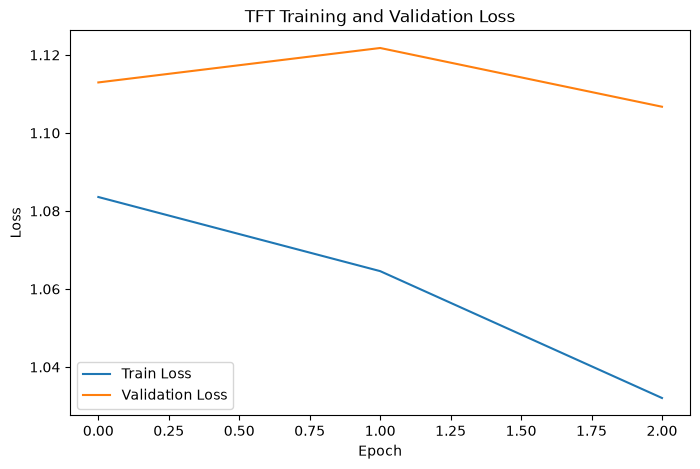

In [48]:

plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TFT Training and Validation Loss")
plt.legend()
plt.show()

# ============================================================
# 37. Validation Metrics
# ============================================================


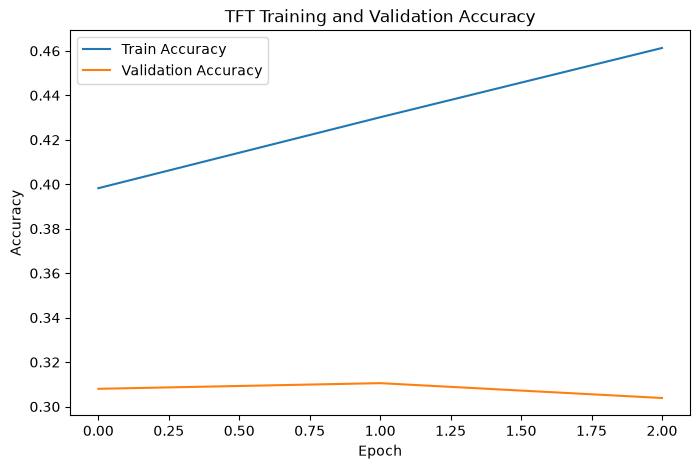

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TFT Training and Validation Accuracy")
plt.legend()
plt.show()

# ============================================================
# 38. Test Set Evaluation - CPU Friendly
# ============================================================

In [51]:

model.eval()

test_predictions = []
test_targets = []

with torch.inference_mode():

    for batch_idx, (X_batch, y_batch) in enumerate(test_loader):

        X_batch = X_batch.to(device)

        logits, _ = model(X_batch)

        predictions = torch.argmax(logits, dim=1)

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_targets.extend(
            y_batch.numpy()
        )

        if (batch_idx + 1) % 50 == 0:
            print(
                f"Processed {batch_idx + 1}/{len(test_loader)} batches"
            )

print("Test evaluation completed!")
print("Number of test samples:", len(test_targets))

Processed 50/5661 batches
Processed 100/5661 batches
Processed 150/5661 batches
Processed 200/5661 batches
Processed 250/5661 batches
Processed 300/5661 batches
Processed 350/5661 batches
Processed 400/5661 batches
Processed 450/5661 batches
Processed 500/5661 batches
Processed 550/5661 batches
Processed 600/5661 batches
Processed 650/5661 batches
Processed 700/5661 batches
Processed 750/5661 batches
Processed 800/5661 batches
Processed 850/5661 batches
Processed 900/5661 batches
Processed 950/5661 batches
Processed 1000/5661 batches
Processed 1050/5661 batches
Processed 1100/5661 batches
Processed 1150/5661 batches
Processed 1200/5661 batches
Processed 1250/5661 batches
Processed 1300/5661 batches
Processed 1350/5661 batches
Processed 1400/5661 batches
Processed 1450/5661 batches
Processed 1500/5661 batches
Processed 1550/5661 batches
Processed 1600/5661 batches
Processed 1650/5661 batches
Processed 1700/5661 batches
Processed 1750/5661 batches
Processed 1800/5661 batches
Processed 18

# ============================================================
# 39. Test Metrics
# ============================================================


In [52]:

test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

test_precision = precision_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

print("TFT Test Results")
print("----------------")
print(f"Accuracy:        {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall:    {test_recall:.4f}")
print(f"Macro F1:        {test_f1:.4f}")


TFT Test Results
----------------
Accuracy:        0.4155
Macro Precision: 0.4211
Macro Recall:    0.3787
Macro F1:        0.3304


# ============================================================
# 40. Classification Report
# ============================================================


In [53]:

class_names = [
    "Down",
    "Stable",
    "Up"
]

print(
    classification_report(
        test_targets,
        test_predictions,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Down       0.41      0.84      0.55    139146
      Stable       0.36      0.13      0.20     88737
          Up       0.49      0.16      0.24    134418

    accuracy                           0.42    362301
   macro avg       0.42      0.38      0.33    362301
weighted avg       0.43      0.42      0.35    362301



# ============================================================
# 41. Confusion Matrix
# ============================================================


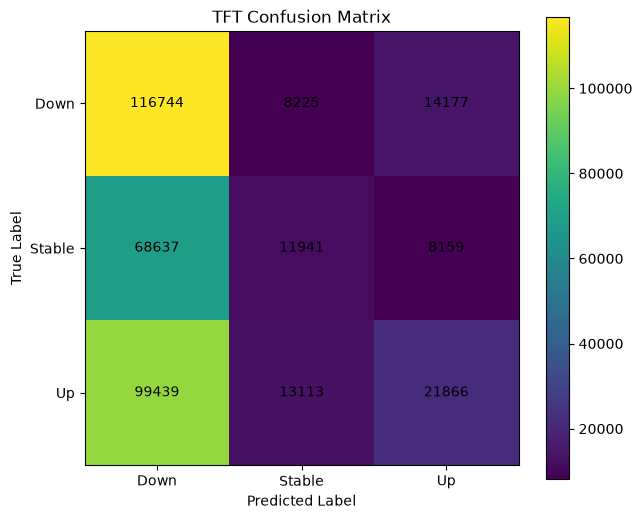

In [54]:

cm = confusion_matrix(
    test_targets,
    test_predictions
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("TFT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(NUM_CLASSES),
    class_names
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

# ============================================================
# 42. Final TFT Results Summary
# ============================================================

In [55]:


tft_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],
    "Test Result": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        f1_score(
            test_targets,
            test_predictions,
            average="weighted",
            zero_division=0
        )
    ]
})

print("Final TFT Test Results")
print("======================")
display(tft_results)

Final TFT Test Results


,Metric,Test Result
0,Accuracy,0.415541
1,Macro Precision,0.421128
2,Macro Recall,0.378747
3,Macro F1,0.330428
4,Weighted F1,0.350287


# ============================================================
# 43. Save TFT Results
# ============================================================

In [56]:

results_path = "tft_test_results.csv"

tft_results.to_csv(
    results_path,
    index=False
)

print(f"TFT results saved to: {results_path}")

TFT results saved to: tft_test_results.csv


## Conclusion

The Temporal Fusion Transformer (TFT) component was trained on FI-2010
Level-2 Limit Order Book sequences for three-class next-movement
classification: Down, Stable, and Up.

The final test evaluation achieved:

- Accuracy: 41.55%
- Macro Precision: 42.11%
- Macro Recall: 37.87%
- Macro F1: 33.04%

The results show that the model currently performs strongest on the
Down class, while Stable and Up require further improvement.

The trained TFT component provides the LOB-side representation that
will later be combined with the FinBERT sentiment representation
during the multimodal fusion stage.

No fusion model is implemented in this notebook.